In [1]:
import pandas as pd
import numpy as np
import glob


def _to_bool_flag(x):
    """Convert typical truthy/falsey strings to bool."""
    if isinstance(x, str):
        s = x.strip().lower()
        if s in {"1", "True", "true", "yes"}:
            return True
        if s in {"0", "False", "false", "no"}:
            return False
    return bool(x)

def _parse_float_or_none(x):
    try:
        return float(str(x).strip())
    except Exception:
        return None

def _answer_value_correct(gt_val, pred_val, rel_tol=1e-3):
    """
    gt_val, pred_val: values from answer_value columns.
    rel_tol = 0.001 => 0.1% relative tolerance.
    """
    gt_str = str(gt_val).strip()
    pred_str = str(pred_val).strip()
    
    # If either is 'is_blank', treat as categorical
    if gt_str.lower() == "is_blank" or pred_str.lower() == "is_blank":
        return gt_str.lower() == pred_str.lower()
    
    gt_num = _parse_float_or_none(gt_val)
    pred_num = _parse_float_or_none(pred_val)
    
    # If both numeric, use relative tolerance
    if gt_num is not None and pred_num is not None:
        if gt_num == 0:
            return abs(pred_num - gt_num) <= rel_tol  # small absolute tolerance around 0
        rel_err = abs(pred_num - gt_num) / max(abs(gt_num), 1e-12)
        return rel_err <= rel_tol
    
    # Otherwise, fall back to normalized string match
    return gt_str.lower() == pred_str.lower()

def _ref_id_jaccard(gt_ref, pred_ref):
    """
    Jaccard overlap between sets of ref_ids.
    Strings may contain semicolon-separated IDs, or 'is_blank'.
    Case-insensitive.
    """
    def to_set(s):
        if s is None:
            return set()
        s = str(s).strip()
        if not s or s.lower() == "is_blank":
            return set()
        parts = [p.strip().lower() for p in s.split(";") if p.strip()]
        return set(parts)
    
    gt_set = to_set(gt_ref)
    pred_set = to_set(pred_ref)
    
    if not gt_set and not pred_set:
        return 1.0
    union = gt_set | pred_set
    if not union:
        return 0.0
    inter = gt_set & pred_set
    return len(inter) / len(union)


def compute_wattbot_score(
    train_qa_path="train_QA.csv",
    preds_path="train_solutions_qwen.csv",
    id_col="id",
    gt_answer_col="answer_value",
    gt_ref_col="ref_id",
    gt_is_na_col="is_NA",
    pred_answer_col="answer_value",
    pred_ref_col="ref_id",
    pred_is_na_col=None,
    n_examples=10,
    verbose=True,                 # NEW
):
    gt = pd.read_csv(train_qa_path)
    preds = pd.read_csv(preds_path)

    merged = gt.merge(preds, on=id_col, suffixes=("_gt", "_pred"))
    if merged.empty:
        raise ValueError("No overlapping ids between ground truth and predictions.")

    # ----- ground truth NA flags -----
    if gt_is_na_col is not None and gt_is_na_col in merged.columns:
        gt_is_na_series = merged[gt_is_na_col].map(_to_bool_flag)
    elif gt_is_na_col is not None and gt_is_na_col.lower() == "is_blank":
        gt_is_na_series = merged[f"{gt_answer_col}_gt"].astype(str).str.lower().eq("is_blank")
        merged["gt_is_blank_flag"] = gt_is_na_series
    else:
        if "is_NA" in merged.columns:
            gt_is_na_series = merged["is_NA"].map(_to_bool_flag)
        elif "is_blank" in merged.columns:
            gt_is_na_series = merged["is_blank"].map(_to_bool_flag)
        else:
            gt_is_na_series = merged[f"{gt_answer_col}_gt"].astype(str).str.lower().eq("is_blank")
            merged["gt_is_blank_flag"] = gt_is_na_series

    # ----- prediction NA flags -----
    if pred_is_na_col is not None and pred_is_na_col in merged.columns:
        pred_is_na_series = merged[pred_is_na_col].map(_to_bool_flag)
    elif pred_is_na_col is not None and pred_is_na_col.lower() == "is_blank":
        pred_is_na_series = merged[f"{pred_answer_col}_pred"].astype(str).str.lower().eq("is_blank")
        merged["pred_is_blank_flag"] = pred_is_na_series
    else:
        if "is_NA" in merged.columns:
            pred_is_na_series = merged["is_NA"].map(_to_bool_flag)
        elif "is_blank" in merged.columns:
            pred_is_na_series = merged["is_blank"].map(_to_bool_flag)
        else:
            pred_is_na_series = merged[f"{pred_answer_col}_pred"].astype(str).str.lower().eq("is_blank")
            merged["pred_is_blank_flag"] = pred_is_na_series

    ans_scores, ref_scores, na_scores = [], [], []

    # IMPORTANT: don't use merged.iterrows() index to index series; use enumerate
    for i, (_, row) in enumerate(merged.iterrows()):
        gt_ans   = row[f"{gt_answer_col}_gt"]
        pred_ans = row[f"{pred_answer_col}_pred"]
        gt_ref   = row[f"{gt_ref_col}_gt"]
        pred_ref = row[f"{pred_ref_col}_pred"]

        gt_is_na = bool(gt_is_na_series.iloc[i])
        pred_is_na = bool(pred_is_na_series.iloc[i])

        ans_correct = _answer_value_correct(gt_ans, pred_ans)
        ans_scores.append(float(ans_correct))

        ref_j = _ref_id_jaccard(gt_ref, pred_ref)
        ref_scores.append(ref_j)

        if gt_is_na:
            na_scores.append(1.0 if pred_is_na else 0.0)
        else:
            na_scores.append(np.nan)

    merged["answer_score"] = ans_scores
    merged["ref_id_score"] = ref_scores
    merged["is_NA_score"]  = na_scores  # NaN for answerable rows

    na_recall = merged["is_NA_score"].mean()  # ignores NaN
    na_recall_val = 0.0 if pd.isna(na_recall) else float(na_recall)

    mean_answer = float(merged["answer_score"].mean())
    mean_ref    = float(merged["ref_id_score"].mean())

    overall_score = 0.75 * mean_answer + 0.15 * mean_ref + 0.10 * na_recall_val

    merged["wattbot_score"] = overall_score  # broadcast for convenience

    if verbose:
        print(f"Rows compared: {len(merged)}")
        print(f"Mean answer_value score: {mean_answer:.4f}")
        print(f"Mean ref_id score:       {mean_ref:.4f}")
        print(f"NA recall (GT NA only):  {na_recall_val:.4f}")
        print(f"Overall WattBot score:   {overall_score:.4f}")

        incorrect = merged[
            (merged["answer_score"] < 1.0)
            | (merged["ref_id_score"] < 1.0)
            | (merged["is_NA_score"] < 1.0)
        ]
        if not incorrect.empty and n_examples > 0:
            print(f"\nExamples (up to {n_examples}):")
            for _, r in incorrect.head(n_examples).iterrows():
                print("-" * 80)
                print(f"id: {r[id_col]}")
                print(f"GT answer_value:   {r[f'{gt_answer_col}_gt']}")
                print(f"Pred answer_value: {r[f'{pred_answer_col}_pred']}")
                print(f"GT ref_id:         {r[f'{gt_ref_col}_gt']}")
                print(f"Pred ref_id:       {r[f'{pred_ref_col}_pred']}")
            print("-" * 80)

    # NEW: return score + components cleanly
    return {
        "merged": merged,
        "overall_score": overall_score,
        "mean_answer": mean_answer,
        "mean_ref": mean_ref,
        "na_recall": na_recall_val,
    }


In [2]:
# results = ["train_solutions_Qwen__Qwen2.5-7B-Instruct.csv", "train_solutions_Qwen__Qwen2.5-32B-Instruct.csv", "train_solutions_Qwen__Qwen2.5-72B-Instruct.csv"]
# for result_file in results:
#     results_df = compute_wattbot_score(
#         train_qa_path="./data/train_QA.csv",
#         preds_path=f"./data/{result_file}",
#         gt_is_na_col="is_blank",   # or "is_blank" / None depending on how you mark NAs
#         n_examples=0,
#     )

In [15]:
glob.glob("data/train_solutions*4bit*.csv")
glob.glob("data/train_solutions*4bit*run_metrics.json")


['data/train_solutions_NVIDIA2_4bit_Qwen__Qwen2.5-7B-Instruct_run_metrics.json',
 'data/train_solutions_NVIDIA2_4bit_Qwen__Qwen2.5-3B-Instruct_run_metrics.json',
 'data/train_solutions_NVIDIA2_4bit_Qwen__Qwen2.5-32B-Instruct_run_metrics.json']

In [4]:
# !pip install matplotlib

Found 3 CSV files
   data/train_solutions_NVIDIA2_4bit_Qwen__Qwen2.5-7B-Instruct.csv
   data/train_solutions_NVIDIA2_4bit_Qwen__Qwen2.5-3B-Instruct.csv
   data/train_solutions_NVIDIA2_4bit_Qwen__Qwen2.5-32B-Instruct.csv

Summary preview:
    system  model_b  overall_wattbot_score  end_to_end_s_per_q  disk_est_gb  \
1  NVIDIA2      3.0               0.235366            2.982657     5.755574   
0  NVIDIA2      7.0               0.560976            3.054123    14.174730   
2  NVIDIA2     32.0               0.678049            6.726642    60.535967   

   gpu_peak_reserved_gb  gpu_energy_total_wh  
1              9.328132             7.918525  
0             12.484346            11.207331  
2             40.177238            31.846990  


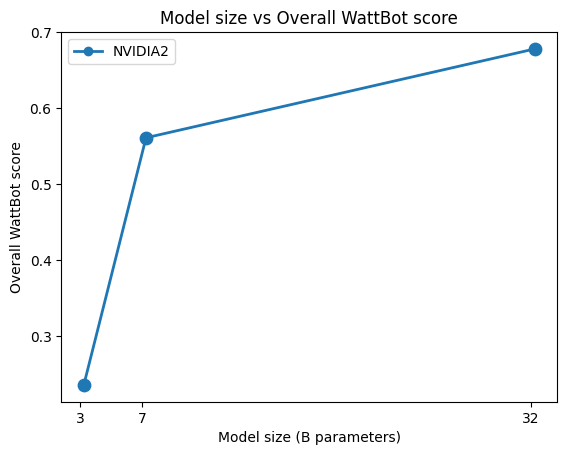

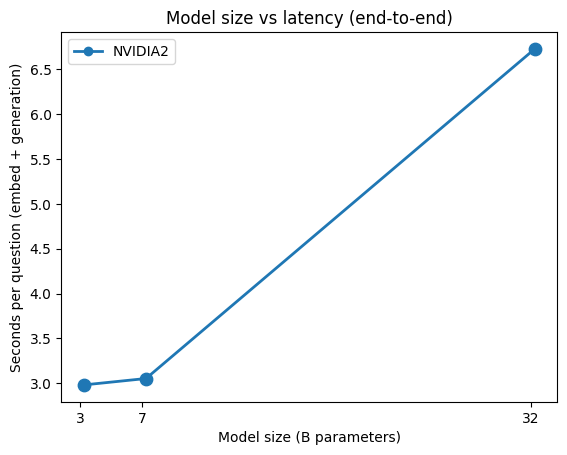

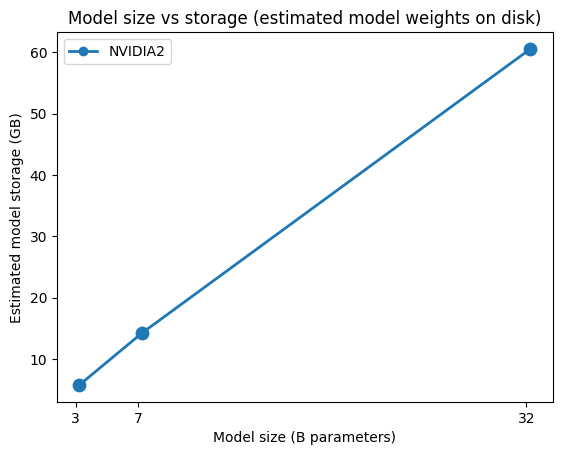

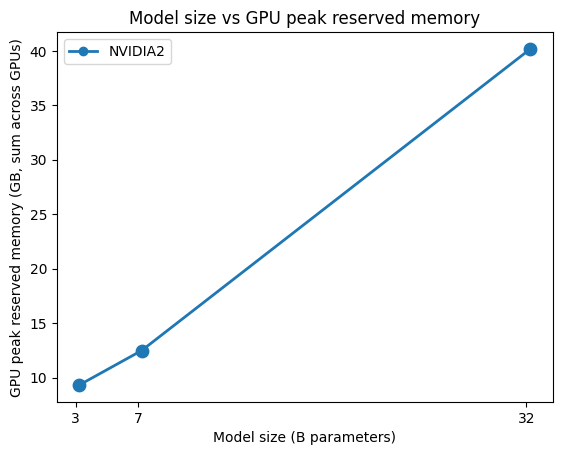

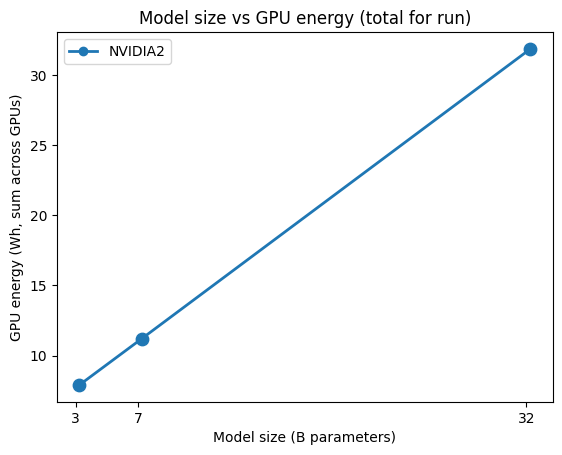

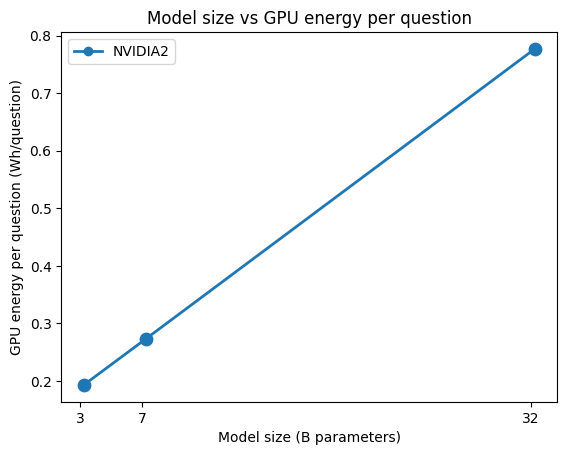

In [20]:
import os, re, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Locate result files
# =========================
# Update these patterns if your files live elsewhere.
SEARCH_GLOBS = [
    "train_solutions*.csv",
    "data/train_solutions*.csv",
    "**/train_solutions*.csv",
]

csv_paths = []
for pat in SEARCH_GLOBS:
    csv_paths.extend(glob.glob(pat, recursive=True))

# De-duplicate while preserving order
seen=set()
csv_paths=[p for p in csv_paths if not (p in seen or seen.add(p))]

print(f"Found {len(csv_paths)} CSV files")
for p in csv_paths[:20]:
    print("  ", p)

if len(csv_paths) == 0:
    raise FileNotFoundError(
        "No files matched train_solutions*.csv\n"
        "Fix: update SEARCH_GLOBS to point at the folder containing your results."
    )

# =========================
# Helpers
# =========================
def system_from_filename(path: str) -> str:
    bn = os.path.basename(path)
    if "NVIDIA1" in bn: return "NVIDIA1"
    if "NVIDIA2" in bn: return "NVIDIA2"
    return "GB10"

def model_id_from_csv_filename(path: str) -> str:
    bn = os.path.basename(path)
    # expects "...__Qwen2.5-7B-Instruct.csv"
    if "__" not in bn:
        return bn.replace(".csv", "")
    after = bn.split("__", 1)[1].replace(".csv", "")
    return "Qwen/" + after

def model_b_from_model_id(model_id: str) -> float:
    m = re.search(r"-(\d+(?:\.\d+)?)B-", model_id)
    return float(m.group(1)) if m else np.nan

def metrics_json_for_csv(csv_path: str) -> str | None:
    # canonical: train_solutions...csv -> train_solutions..._run_metrics.json
    cand = csv_path.replace(".csv", "_run_metrics.json")
    if os.path.exists(cand):
        return cand

    # tolerate a few other naming quirks
    bn = os.path.basename(csv_path).replace(".csv", "")
    folder = os.path.dirname(csv_path) or "."
    fallbacks = glob.glob(os.path.join(folder, bn + "*run_metrics*.json"))
    return fallbacks[0] if fallbacks else None

def _sum_gpu_dict(d: dict, key: str) -> float:
    # d like {"0":{"max_reserved_gb":...},"1":{...}}
    if not isinstance(d, dict):
        return np.nan
    total = 0.0
    found = False
    for _, v in d.items():
        if isinstance(v, dict) and key in v and v[key] is not None:
            total += float(v[key])
            found = True
    return total if found else np.nan

def _sum_energy_wh(d: dict) -> float:
    if not isinstance(d, dict):
        return np.nan
    total = 0.0
    found = False
    for _, v in d.items():
        if v is not None:
            total += float(v)
            found = True
    return total if found else np.nan

def _bytes_to_gb(x: float | int | None) -> float:
    if x is None:
        return np.nan
    return float(x) / (1024**3)

# =========================
# Plotting
# =========================
def plot_lines(df: pd.DataFrame, ycol: str, ylabel: str, title: str, out_path: str):
    # small x offsets so multiple systems don't sit exactly on top of each other
    x_offset = {"GB10": -0.25, "NVIDIA1": 0.00, "NVIDIA2": 0.25}

    plt.figure()
    for sys, g in df.groupby("system"):
        g = g.sort_values("model_b")
        xs = g["model_b"].to_numpy() + x_offset.get(sys, 0.0)
        plt.plot(xs, g[ycol], marker="o", linewidth=2, label=sys, zorder=3)
        plt.scatter(xs, g[ycol], s=80, zorder=4)

    plt.xlabel("Model size (B parameters)")
    plt.ylabel(ylabel)
    plt.title(title)
    base_ticks = sorted([x for x in df["model_b"].unique() if not np.isnan(x)])
    if base_ticks:
        plt.xticks(base_ticks)
    plt.legend()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

# =========================
# Build summary table
# =========================
train_qa_path = "data/train_QA.csv"  # update if you want to compute score

have_score_fn = "compute_wattbot_score" in globals()
if not have_score_fn:
    print("NOTE: compute_wattbot_score() not found in this notebook runtime.")
    print("      Score columns will be NaN unless you run/define it earlier.")

rows = []
for csv_path in csv_paths:
    system = system_from_filename(csv_path)
    model_id = model_id_from_csv_filename(csv_path)
    model_b = model_b_from_model_id(model_id)

    row = {
        "system": system,
        "model_id": model_id,
        "model_b": model_b,
        "csv_path": csv_path,
        "overall_wattbot_score": np.nan,
        # storage / memory / energy placeholders
        "disk_est_gb": np.nan,
        "cpu_rss_peak_gb": np.nan,
        "gpu_peak_alloc_gb": np.nan,
        "gpu_peak_reserved_gb": np.nan,
        "gpu_reserved_after_load_gb": np.nan,
        "gpu_alloc_after_load_gb": np.nan,
        "gpu_energy_total_wh": np.nan,
        "gpu_energy_wh_per_q": np.nan,
    }

    # score (optional)
    if have_score_fn and os.path.exists(train_qa_path):
        score_out = compute_wattbot_score(
            train_qa_path=train_qa_path,
            preds_path=csv_path,
            gt_is_na_col="is_NA",
            pred_is_na_col="is_blank",
            n_examples=0,
            verbose=False,
        )
        row["overall_wattbot_score"] = score_out.get("overall_score", np.nan)

    # metrics json (optional)
    jpath = metrics_json_for_csv(csv_path)
    row["metrics_json_path"] = jpath
    if jpath:
        with open(jpath, "r", encoding="utf-8") as f:
            d = json.load(f)

        md = d.get("run_metadata", {}) or {}
        t  = d.get("timings", {}) or {}

        # --- storage ---
        # you record an estimated disk size in bytes (model weights)
        row["disk_est_gb"] = _bytes_to_gb(md.get("disk_bytes_est", None))

        # --- memory ---
        row["cpu_rss_peak_gb"] = _bytes_to_gb(t.get("cpu_rss_peak_bytes", None))

        peak = t.get("gpu_peak_mem", None)
        row["gpu_peak_alloc_gb"]     = _sum_gpu_dict(peak, "max_allocated_gb")
        row["gpu_peak_reserved_gb"]  = _sum_gpu_dict(peak, "max_reserved_gb")

        after = md.get("gpu_mem_after_load", None)
        row["gpu_reserved_after_load_gb"] = _sum_gpu_dict(after, "reserved_gb")
        row["gpu_alloc_after_load_gb"]    = _sum_gpu_dict(after, "allocated_gb")

        # --- energy ---
        # prefer timings if present; fall back to run_metadata
        energy = t.get("gpu_energy_wh", None)
        if energy is None:
            energy = md.get("gpu_energy_wh", None)
        row["gpu_energy_total_wh"] = _sum_energy_wh(energy)

        # also compute Wh/question if num_questions exists
        n_q = t.get("num_questions", None)
        if n_q:
            row["gpu_energy_wh_per_q"] = row["gpu_energy_total_wh"] / float(n_q)

        # latency (keeping your existing columns)
        gen_s = t.get("timing_generation_s", None)
        emb_s = t.get("timing_embedding_s", 0.0)
        if gen_s is not None and n_q:
            row["gen_s_per_q"] = gen_s / float(n_q)
            row["end_to_end_s_per_q"] = (float(gen_s) + float(emb_s)) / float(n_q)
        else:
            row["gen_s_per_q"] = np.nan
            row["end_to_end_s_per_q"] = np.nan
    else:
        row["gen_s_per_q"] = np.nan
        row["end_to_end_s_per_q"] = np.nan

    rows.append(row)

summary_df = pd.DataFrame(rows).sort_values(["system", "model_b"])
print("\nSummary preview:")
display_cols = [
    "system","model_b","overall_wattbot_score","end_to_end_s_per_q",
    "disk_est_gb","gpu_peak_reserved_gb","gpu_energy_total_wh"
]
print(summary_df[display_cols])

# =========================
# Plots (existing + new)
# =========================
# Existing
if "overall_wattbot_score" in summary_df.columns:
    plot_lines(
        summary_df,
        ycol="overall_wattbot_score",
        ylabel="Overall WattBot score",
        title="Model size vs Overall WattBot score",
        out_path="model_size_vs_wattbot_score.png",
    )

plot_lines(
    summary_df,
    ycol="end_to_end_s_per_q",
    ylabel="Seconds per question (embed + generation)",
    title="Model size vs latency (end-to-end)",
    out_path="model_size_vs_latency_end_to_end.png",
)

# New: storage vs model size (estimated model weights on disk)
plot_lines(
    summary_df,
    ycol="disk_est_gb",
    ylabel="Estimated model storage (GB)",
    title="Model size vs storage (estimated model weights on disk)",
    out_path="model_size_vs_storage_gb.png",
)

# New: memory vs model size (GPU peak reserved across all GPUs)
plot_lines(
    summary_df,
    ycol="gpu_peak_reserved_gb",
    ylabel="GPU peak reserved memory (GB, sum across GPUs)",
    title="Model size vs GPU peak reserved memory",
    out_path="model_size_vs_gpu_peak_reserved_gb.png",
)

# New: energy vs model size (total GPU energy for the run)
plot_lines(
    summary_df,
    ycol="gpu_energy_total_wh",
    ylabel="GPU energy (Wh, sum across GPUs)",
    title="Model size vs GPU energy (total for run)",
    out_path="model_size_vs_gpu_energy_total_wh.png",
)

# Optional: energy normalized per question (often easier to compare across runs)
plot_lines(
    summary_df,
    ycol="gpu_energy_wh_per_q",
    ylabel="GPU energy per question (Wh/question)",
    title="Model size vs GPU energy per question",
    out_path="model_size_vs_gpu_energy_wh_per_q.png",
)
